## Análisis de datos - Clase 3
---

## Taller práctico parte 1 - análisis inicial de un dataset
---


Vamos a realizar una actividad con un dataset con datos del Servicio Meteorológico Nacional Argentino. El dataset contiene estadísticas climáticas normales (período 1991-2020).

Fuente: https://www.smn.gob.ar/descarga-de-datos

Consigna: realizar un EDA completo de los datos, incluyendo estadísticas descriptivas de las variables numéricas (valor central, dispersión, etc.), análisis de variables categóricas (frecuencias, entropía, etc.), visualizaciones y relaciones entre variables.

Resumen de variables:
* estación, provincia, latitud, longitud, altitud, número y NroOACI (estos dos últimos identifican las estaciones)
* mes
* temperatura media, máxima y mínima
* humedad relativa
* velocidad del viento
* nubosidad total (en meteorología, la nubosidad se mide en octas (0, despejado - 8 completamente cubierto), que representan la fracción del cielo cubierta por nubes)
* precipitación
* frecuencia de días con precipitación superior a 0,1 mm.

In [2]:
import pandas as pd
import numpy as np
from datetime import timedelta
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
smn_historico = pd.read_csv('../datasets/smn/smn_historico.csv', na_values=['S/D'])

In [34]:
smn_historico.shape

(1176, 16)

In [31]:
smn_historico.head(30)

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9
5,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,Jun,4.5,76.3,4.2,54.6,12.3,15.5,9.4,12.2
6,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,Jul,5.0,75.5,4.1,64.3,11.3,14.4,8.4,13.2
7,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,Ago,5.0,73.6,3.9,61.5,12.9,16.5,9.7,14.0
8,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,Sep,5.5,71.1,3.8,72.6,14.7,18.3,11.5,16.6
9,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,Oct,7.5,70.6,3.9,104.7,17.7,21.1,14.3,17.2


In [38]:
formosa = smn_historico[smn_historico['provincia'].str.contains('FORMOSA', case=False, na=False)]
print(formosa['estacion'].unique())

['FORMOSA AERO' 'LAS LOMITAS']


In [37]:
print(smn_historico['estacion'].unique())

['AEROPARQUE AERO' 'AZUL AERO' 'BAHIA BLANCA AERO' 'BARILOCHE AERO'
 'BASE BELGRANO II' 'BASE CARLINI (EX JUBANY)' 'BASE ESPERANZA'
 'BASE MARAMBIO' 'BASE ORCADAS' 'BASE SAN MARTIN'
 'BERNARDO DE IRIGOYEN AERO' 'BOLIVAR AERO' 'BUENOS AIRES OBSERVATORIO'
 'CATAMARCA AERO' 'CERES AERO' 'CHAMICAL AERO' 'CHILECITO AERO'
 'COMODORO RIVADAVIA AERO' 'CONCORDIA AERO' 'CORONEL PRINGLES AERO'
 'CORONEL SUAREZ AERO' 'CORRIENTES AERO' 'CORDOBA AERO'
 'CORDOBA OBSERVATORIO' 'DOLORES AERO' 'EL BOLSON AERO' 'EL CALAFATE AERO'
 'EL PALOMAR AERO' 'EL TREBOL' 'ESQUEL AERO' 'EZEIZA AERO' 'FORMOSA AERO'
 'GENERAL PICO AERO' 'GOBERNADOR GREGORES AERO' 'GUALEGUAYCHU AERO'
 'IGUAZU AERO' 'JACHAL' 'JUJUY AERO' 'JUJUY U N' 'JUNIN AERO'
 'LA PLATA AERO' 'LA QUIACA OBSERVATORIO' 'LA RIOJA AERO' 'LABOULAYE AERO'
 'LAS FLORES' 'LAS LOMITAS' 'MALARGUE AERO' 'MAQUINCHAO'
 'MAR DEL PLATA AERO' 'MARCOS JUAREZ AERO' 'MENDOZA AERO'
 'MENDOZA OBSERVATORIO' 'MONTE CASEROS AERO' 'NEUQUEN AERO'
 'NUEVE DE JULIO' 'OBERA' 'OL

In [6]:
smn_historico.describe()

,altura,numero,LAT_decimal,LON_decimal,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
count,1152.000000,1152.000000,1152.000000,1152.000000,1061.000000,1110.000000,1166.000000,1061.000000,1167.000000,1158.000000,1124.000000,708.000000
mean,328.812500,87570.031250,-36.347049,-62.623785,5.097455,68.005405,3.840137,68.234873,14.834190,21.223834,9.102847,13.011582
std,468.195292,450.772923,10.369416,5.591299,2.536586,11.027475,0.888284,51.674519,8.178787,8.938676,7.778743,5.554040
min,5.000000,87007.000000,-77.866667,-72.050000,0.000000,25.700000,1.300000,0.000000,-20.900000,-17.500000,-25.000000,3.900000
25%,45.250000,87284.250000,-38.437500,-66.458333,3.100000,61.325000,3.300000,23.300000,10.300000,17.025000,4.500000,9.200000
50%,141.000000,87520.500000,-34.500000,-63.183333,5.200000,70.100000,3.700000,58.900000,15.700000,22.400000,9.900000,11.800000
75%,450.000000,87697.750000,-29.891667,-58.775000,7.000000,76.400000,4.200000,106.500000,21.200000,27.900000,15.100000,15.900000
max,3459.000000,89066.000000,-22.100000,-34.616667,13.800000,90.200000,7.500000,277.900000,28.300000,35.500000,22.500000,36.500000


In [9]:
smn_historico.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   estacion      1176 non-null   object 
 1   provincia     1152 non-null   object 
 2   altura        1152 non-null   float64
 3   numero        1152 non-null   float64
 4   NroOACI       1140 non-null   object 
 5   LAT_decimal   1152 non-null   float64
 6   LON_decimal   1152 non-null   float64
 7   mes_txt       1176 non-null   object 
 8   prec_sup_1mm  1061 non-null   float64
 9   humedad       1110 non-null   float64
 10  nubosidad     1166 non-null   float64
 11  prec_mm       1061 non-null   float64
 12  temp          1167 non-null   float64
 13  temp_max      1158 non-null   float64
 14  temp_min      1124 non-null   float64
 15  viento        708 non-null    float64
dtypes: float64(12), object(4)
memory usage: 147.1+ KB


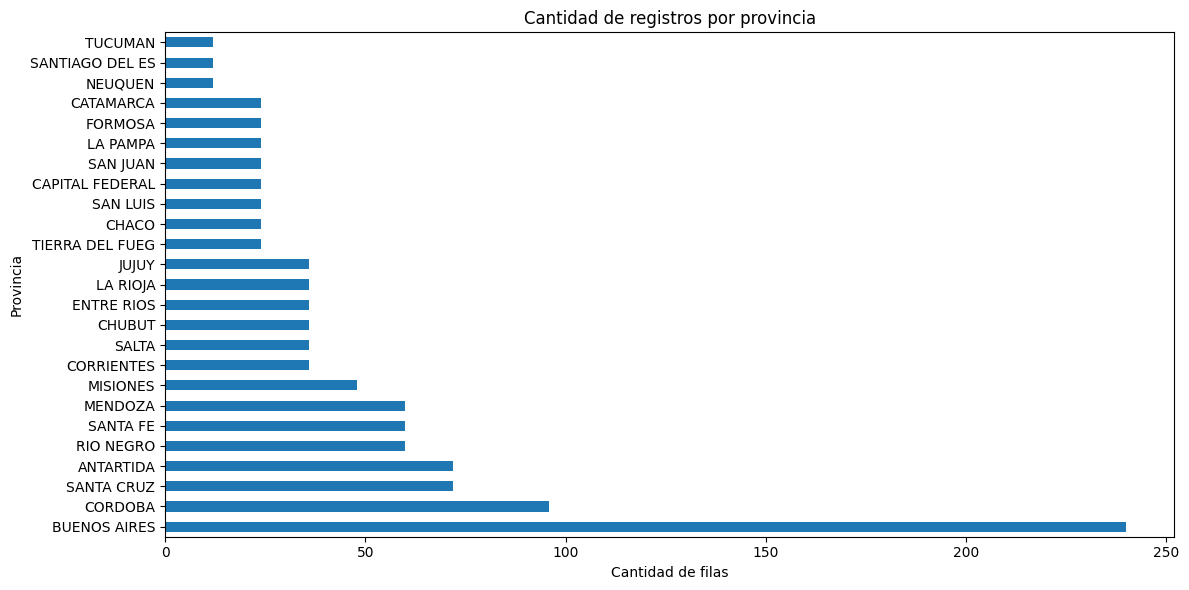

In [11]:
# Add this after the existing code in your notebook

# Gráfico de cantidad de filas por provincia
plt.figure(figsize=(12, 6))
smn_historico['provincia'].value_counts().plot(kind='barh')
plt.xlabel('Cantidad de filas')
plt.ylabel('Provincia')
plt.title('Cantidad de registros por provincia')
plt.tight_layout()
plt.show()

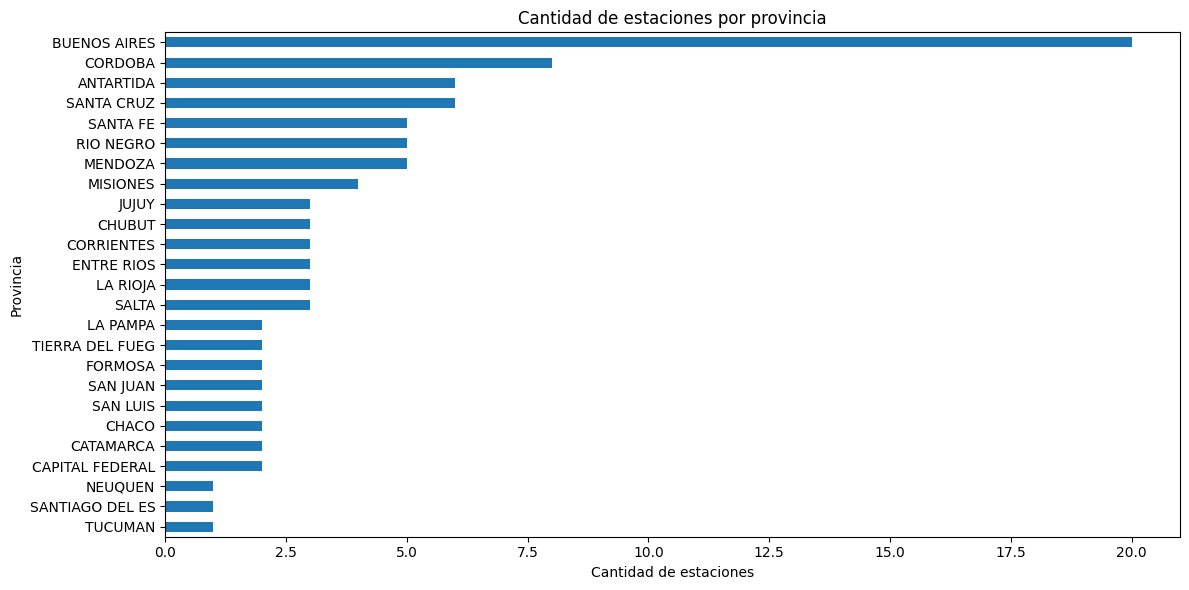

In [14]:
# Gráfico de cantidad de estaciones por provincia
plt.figure(figsize=(12, 6))
smn_historico.groupby('provincia')['estacion'].nunique().sort_values(ascending=True).plot(kind='barh')
plt.xlabel('Cantidad de estaciones')
plt.ylabel('Provincia')
plt.title('Cantidad de estaciones por provincia')
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

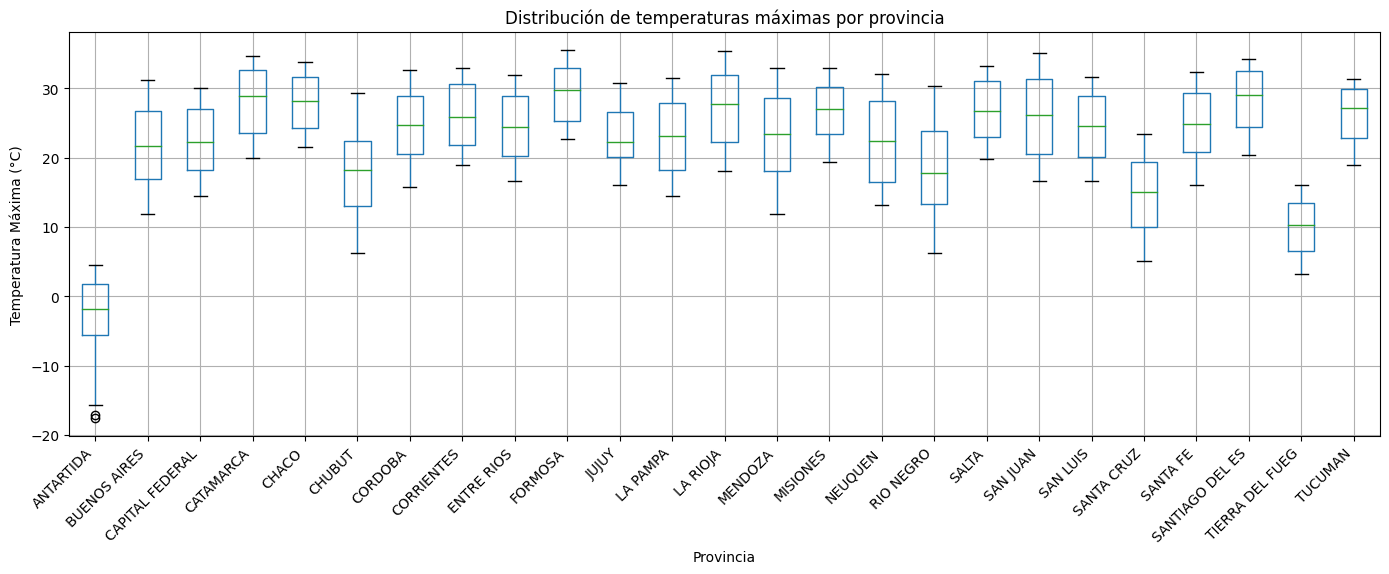

In [19]:
# Boxplot de temperaturas máximas por provincia
plt.figure(figsize=(14, 6))
smn_historico.boxplot(column='temp_max', by='provincia', figsize=(14, 6))
plt.xlabel('Provincia')
plt.ylabel('Temperatura Máxima (°C)')
plt.title('Distribución de temperaturas máximas por provincia')
plt.suptitle('')  # Elimina el título automático
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

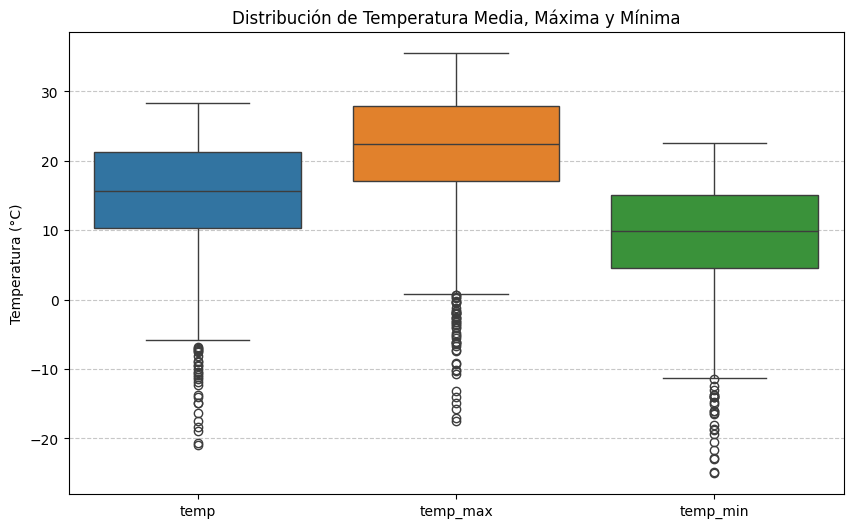

In [20]:
# Boxplot para comparar las distribuciones de temperatura
plt.figure(figsize=(10, 6))
sns.boxplot(data=smn_historico[['temp', 'temp_max', 'temp_min']])
plt.title('Distribución de Temperatura Media, Máxima y Mínima')
plt.ylabel('Temperatura (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

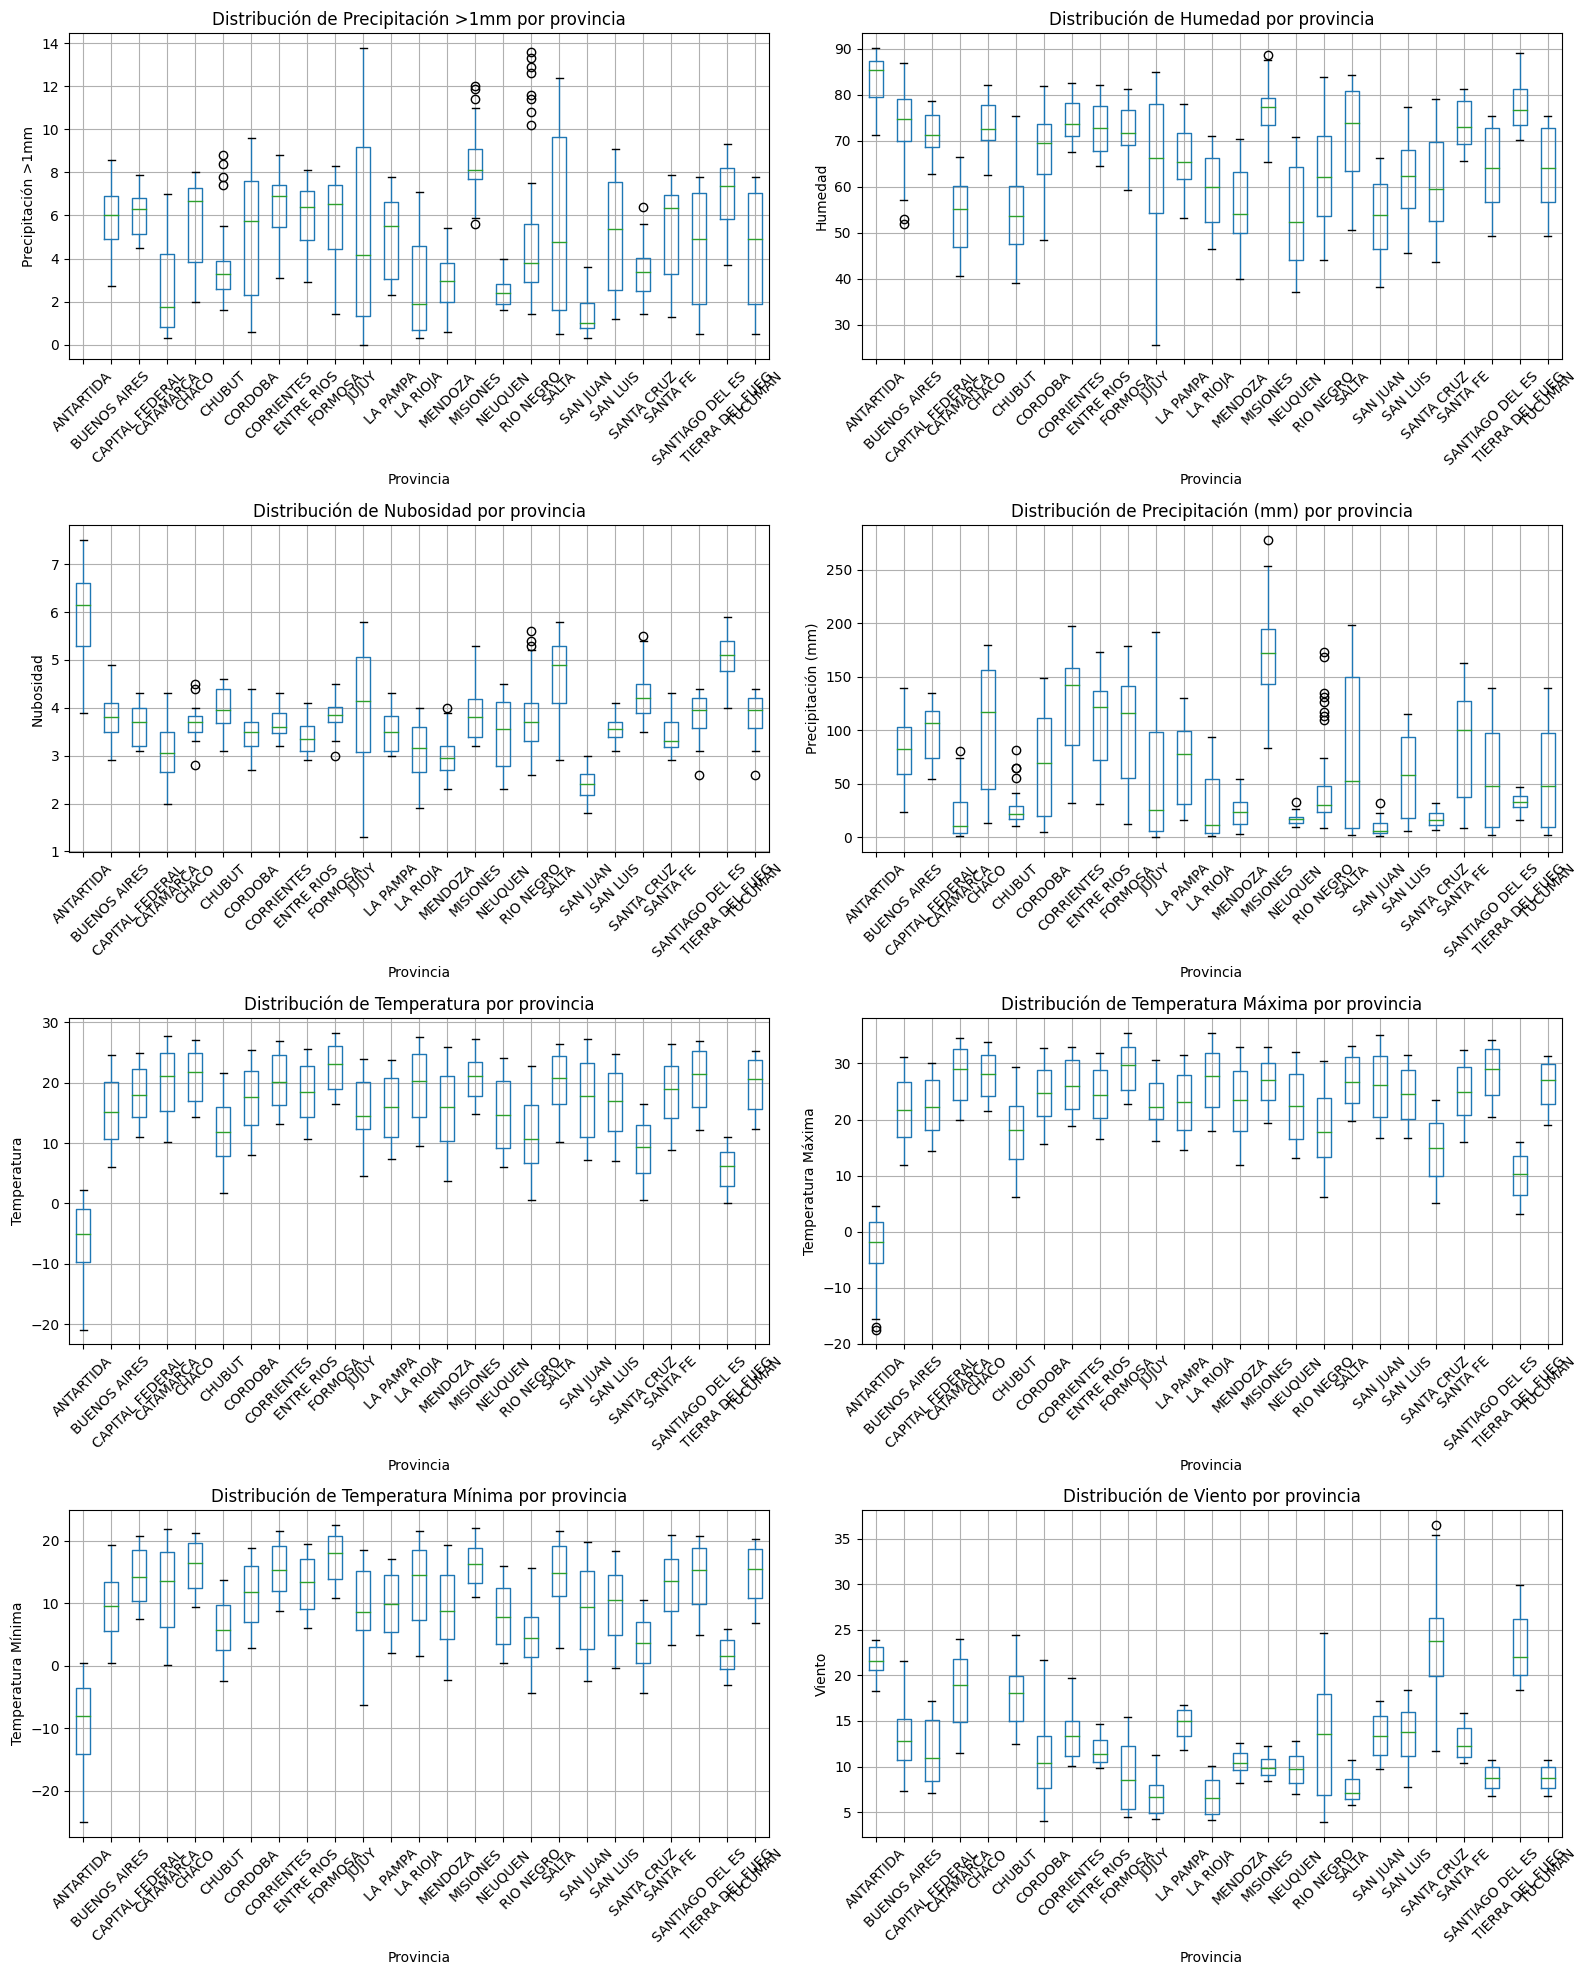

In [21]:
# Boxplots por provincia para cada variable numérica
variables = ['prec_sup_1mm', 'humedad', 'nubosidad', 'prec_mm', 'temp', 'temp_max', 'temp_min', 'viento']
titulos = ['Precipitación >1mm', 'Humedad', 'Nubosidad', 'Precipitación (mm)', 
           'Temperatura', 'Temperatura Máxima', 'Temperatura Mínima', 'Viento']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, (var, titulo) in enumerate(zip(variables, titulos)):
    smn_historico.boxplot(column=var, by='provincia', ax=axes[i])
    axes[i].set_xlabel('Provincia')
    axes[i].set_ylabel(titulo)
    axes[i].set_title(f'Distribución de {titulo} por provincia')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

['CAPITAL FEDERAL' 'BUENOS AIRES' 'RIO NEGRO' 'ANTARTIDA' 'MISIONES'
 'CATAMARCA' 'SANTA FE' 'LA RIOJA' 'CHUBUT' 'ENTRE RIOS' nan 'CORRIENTES'
 'CORDOBA' 'SANTA CRUZ' 'FORMOSA' 'LA PAMPA' 'SAN JUAN' 'JUJUY' 'MENDOZA'
 'NEUQUEN' 'SALTA' 'CHACO' 'TIERRA DEL FUEG' 'SAN LUIS' 'SANTIAGO DEL ES'
 'TUCUMAN']


/var/folders/6k/5h802l7x7nl4z6q7y2xjf4qc0000gn/T/ipykernel_9405/2533952851.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  formosa['mes_txt'] = pd.Categorical(formosa['mes_txt'], categories=orden_meses, ordered=True)


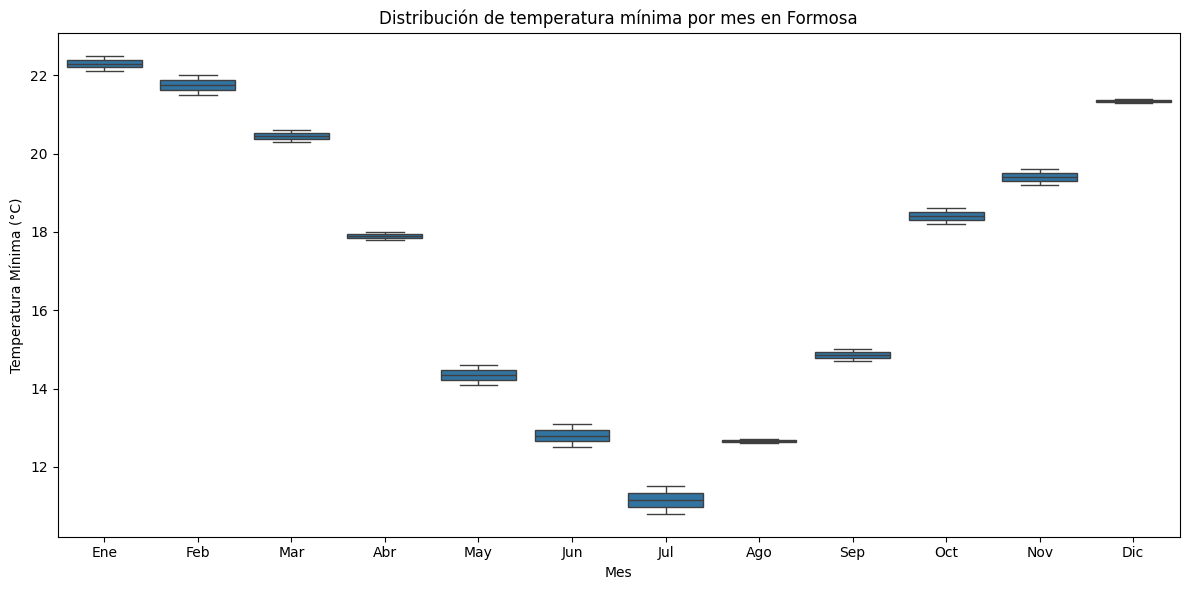

In [42]:
# Distribución de temperatura mínima por mes en Formosa
# Primero verificamos si existe Formosa
print(smn_historico['provincia'].unique())

# Filtrar por Formosa (ajustar el nombre si es necesario)
formosa = smn_historico[smn_historico['provincia'].str.contains('FORMOSA', case=False, na=False)]

if len(formosa) > 0:
    plt.figure(figsize=(12, 6))
    # Ordenar meses correctamente
    orden_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    formosa['mes_txt'] = pd.Categorical(formosa['mes_txt'], categories=orden_meses, ordered=True)
    formosa_sorted = formosa.sort_values('mes_txt')
    
    sns.boxplot(data=formosa_sorted, x='mes_txt', y='temp_min')
    plt.xlabel('Mes')
    plt.ylabel('Temperatura Mínima (°C)')
    plt.title('Distribución de temperatura mínima por mes en Formosa')
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron datos para Formosa")

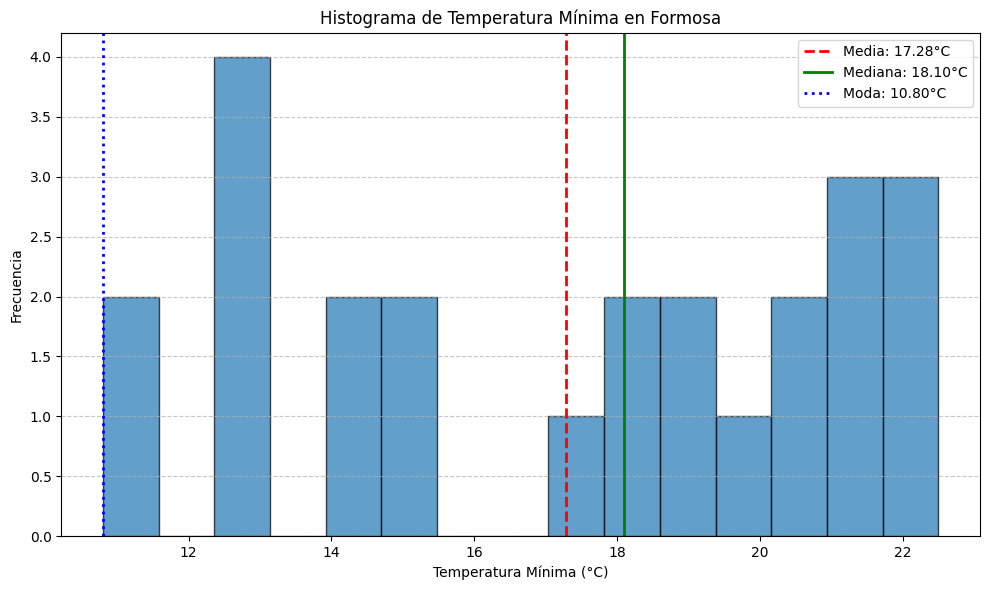

In [44]:
# Histograma de frecuencia de temperatura mínima para Formosa
formosa = smn_historico[smn_historico['provincia'].str.contains('FORMOSA', case=False, na=False)]

# Calcular estadísticos
media = formosa['temp_min'].mean()
mediana = formosa['temp_min'].median()
moda = formosa['temp_min'].mode()[0]

plt.figure(figsize=(10, 6))
plt.hist(formosa['temp_min'].dropna(), bins=15, edgecolor='black', alpha=0.7)

# Agregar líneas verticales para media, mediana y moda
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}°C')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}°C')
plt.axvline(moda, color='blue', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}°C')

plt.xlabel('Temperatura Mínima (°C)')
plt.ylabel('Frecuencia')
plt.title('Histograma de Temperatura Mínima en Formosa')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

['CAPITAL FEDERAL' 'BUENOS AIRES' 'RIO NEGRO' 'ANTARTIDA' 'MISIONES'
 'CATAMARCA' 'SANTA FE' 'LA RIOJA' 'CHUBUT' 'ENTRE RIOS' nan 'CORRIENTES'
 'CORDOBA' 'SANTA CRUZ' 'FORMOSA' 'LA PAMPA' 'SAN JUAN' 'JUJUY' 'MENDOZA'
 'NEUQUEN' 'SALTA' 'CHACO' 'TIERRA DEL FUEG' 'SAN LUIS' 'SANTIAGO DEL ES'
 'TUCUMAN']


/var/folders/6k/5h802l7x7nl4z6q7y2xjf4qc0000gn/T/ipykernel_9405/2025989306.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  formosa['mes_txt'] = pd.Categorical(formosa['mes_txt'], categories=orden_meses, ordered=True)


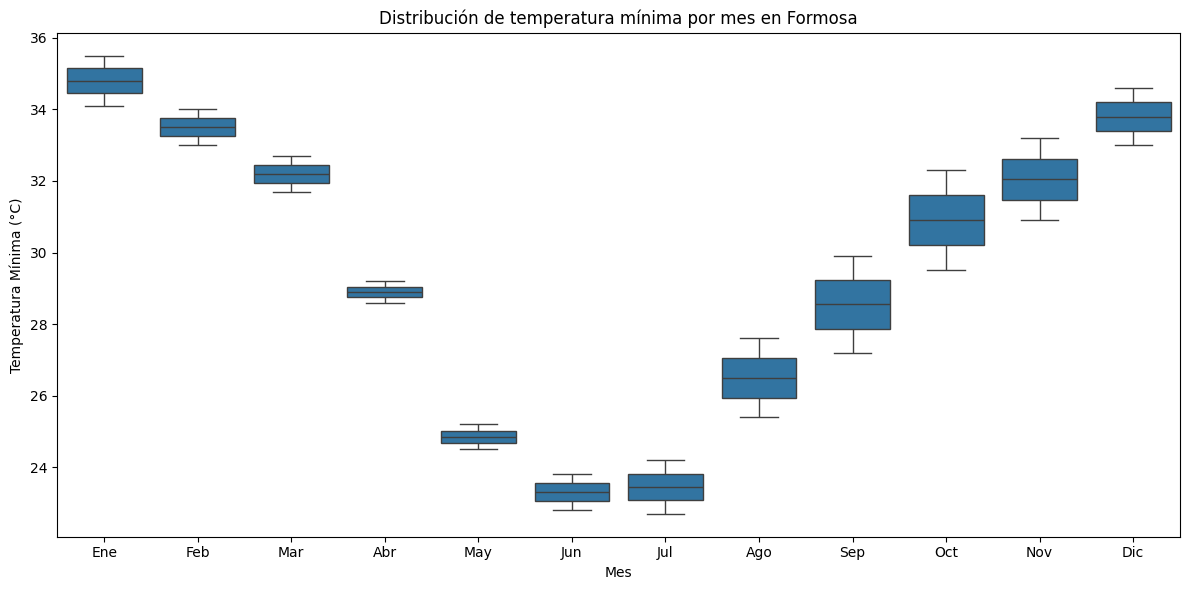

In [40]:
# Distribución de temperatura mínima por mes en Formosa
# Primero verificamos si existe Formosa
print(smn_historico['provincia'].unique())

# Filtrar por Formosa (ajustar el nombre si es necesario)
formosa = smn_historico[smn_historico['provincia'].str.contains('FORMOSA', case=False, na=False)]

if len(formosa) > 0:
    plt.figure(figsize=(12, 6))
    # Ordenar meses correctamente
    orden_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    formosa['mes_txt'] = pd.Categorical(formosa['mes_txt'], categories=orden_meses, ordered=True)
    formosa_sorted = formosa.sort_values('mes_txt')
    
    sns.boxplot(data=formosa_sorted, x='mes_txt', y='temp_max')
    plt.xlabel('Mes')
    plt.ylabel('Temperatura Mínima (°C)')
    plt.title('Distribución de temperatura mínima por mes en Formosa')
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron datos para Formosa")

['CAPITAL FEDERAL' 'BUENOS AIRES' 'RIO NEGRO' 'ANTARTIDA' 'MISIONES'
 'CATAMARCA' 'SANTA FE' 'LA RIOJA' 'CHUBUT' 'ENTRE RIOS' nan 'CORRIENTES'
 'CORDOBA' 'SANTA CRUZ' 'FORMOSA' 'LA PAMPA' 'SAN JUAN' 'JUJUY' 'MENDOZA'
 'NEUQUEN' 'SALTA' 'CHACO' 'TIERRA DEL FUEG' 'SAN LUIS' 'SANTIAGO DEL ES'
 'TUCUMAN']


/var/folders/6k/5h802l7x7nl4z6q7y2xjf4qc0000gn/T/ipykernel_9405/925049870.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  formosa['mes_txt'] = pd.Categorical(formosa['mes_txt'], categories=orden_meses, ordered=True)


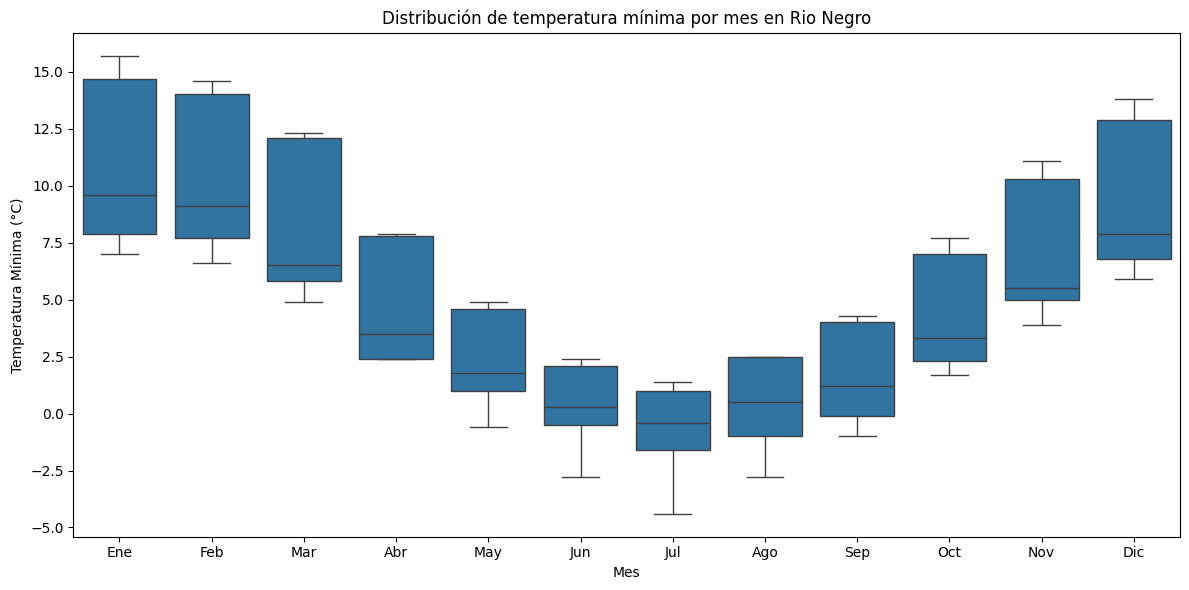

In [43]:
# Distribución de temperatura mínima por mes en Formosa
# Primero verificamos si existe Formosa
print(smn_historico['provincia'].unique())

# Filtrar por Formosa (ajustar el nombre si es necesario)
formosa = smn_historico[smn_historico['provincia'].str.contains('RIO NEGRO', case=False, na=False)]

if len(formosa) > 0:
    plt.figure(figsize=(12, 6))
    # Ordenar meses correctamente
    orden_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    formosa['mes_txt'] = pd.Categorical(formosa['mes_txt'], categories=orden_meses, ordered=True)
    formosa_sorted = formosa.sort_values('mes_txt')
    
    sns.boxplot(data=formosa_sorted, x='mes_txt', y='temp_min')
    plt.xlabel('Mes')
    plt.ylabel('Temperatura Mínima (°C)')
    plt.title('Distribución de temperatura mínima por mes en Rio Negro')
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron datos para Formosa")

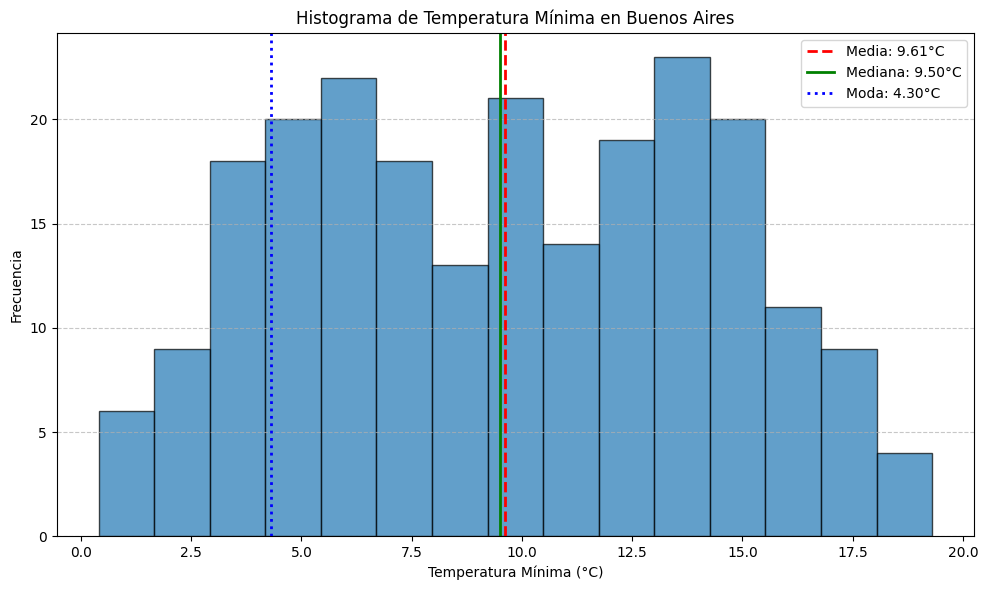

In [46]:
# Histograma de frecuencia de temperatura mínima para Formosa
formosa = smn_historico[smn_historico['provincia'].str.contains('BUENOS AIRES', case=False, na=False)]

# Calcular estadísticos
media = formosa['temp_min'].mean()
mediana = formosa['temp_min'].median()
moda = formosa['temp_min'].mode()[0]

plt.figure(figsize=(10, 6))
plt.hist(formosa['temp_min'].dropna(), bins=15, edgecolor='black', alpha=0.7)

# Agregar líneas verticales para media, mediana y moda
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}°C')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}°C')
plt.axvline(moda, color='blue', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}°C')

plt.xlabel('Temperatura Mínima (°C)')
plt.ylabel('Frecuencia')
plt.title('Histograma de Temperatura Mínima en Buenos Aires')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

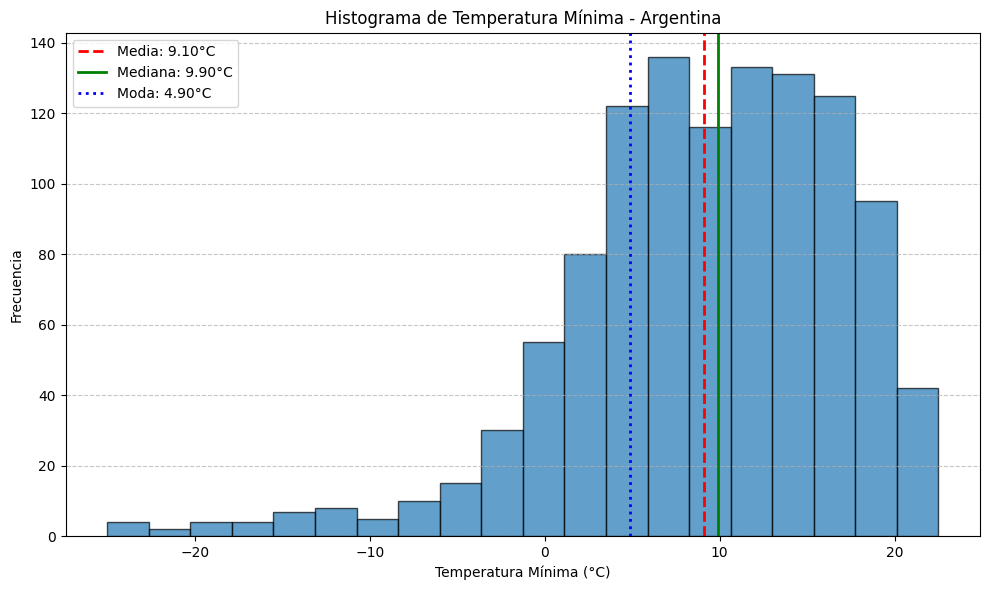

In [47]:
# Histograma de frecuencia de temperatura mínima para todo el dataset
# Calcular estadísticos
media = smn_historico['temp_min'].mean()
mediana = smn_historico['temp_min'].median()
moda = smn_historico['temp_min'].mode()[0]

plt.figure(figsize=(10, 6))
plt.hist(smn_historico['temp_min'].dropna(), bins=20, edgecolor='black', alpha=0.7)

# Agregar líneas verticales para media, mediana y moda
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}°C')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}°C')
plt.axvline(moda, color='blue', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}°C')

plt.xlabel('Temperatura Mínima (°C)')
plt.ylabel('Frecuencia')
plt.title('Histograma de Temperatura Mínima - Argentina')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

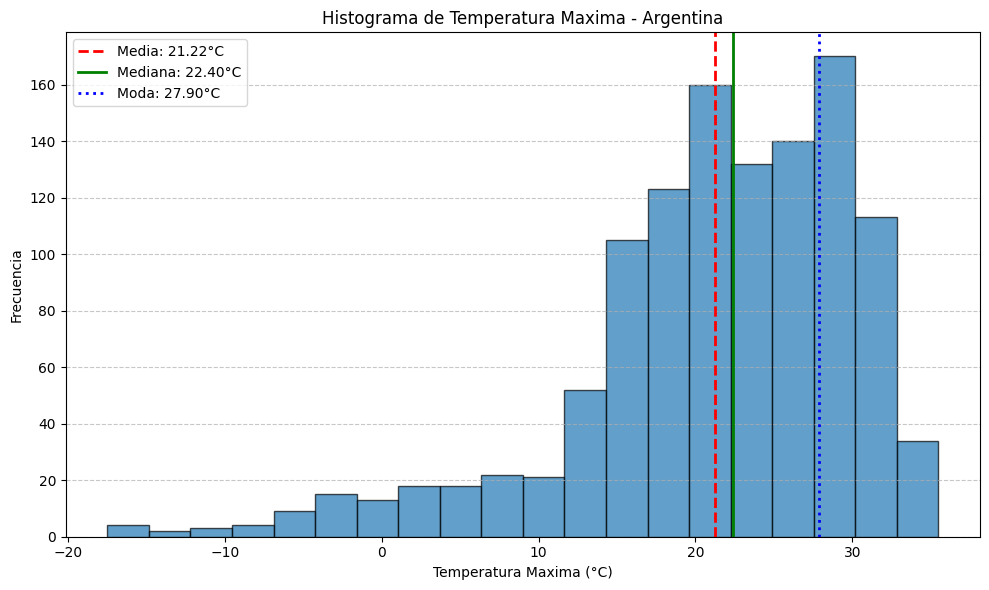

In [50]:
# Histograma de frecuencia de temperatura maxima para todo el dataset
# Calcular estadísticos
media = smn_historico['temp_max'].mean()
mediana = smn_historico['temp_max'].median()
moda = smn_historico['temp_max'].mode()[0]

plt.figure(figsize=(10, 6))
plt.hist(smn_historico['temp_max'].dropna(), bins=20, edgecolor='black', alpha=0.7)

# Agregar líneas verticales para media, mediana y moda
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}°C')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}°C')
plt.axvline(moda, color='blue', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}°C')

plt.xlabel('Temperatura Maxima (°C)')
plt.ylabel('Frecuencia')
plt.title('Histograma de Temperatura Maxima - Argentina')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

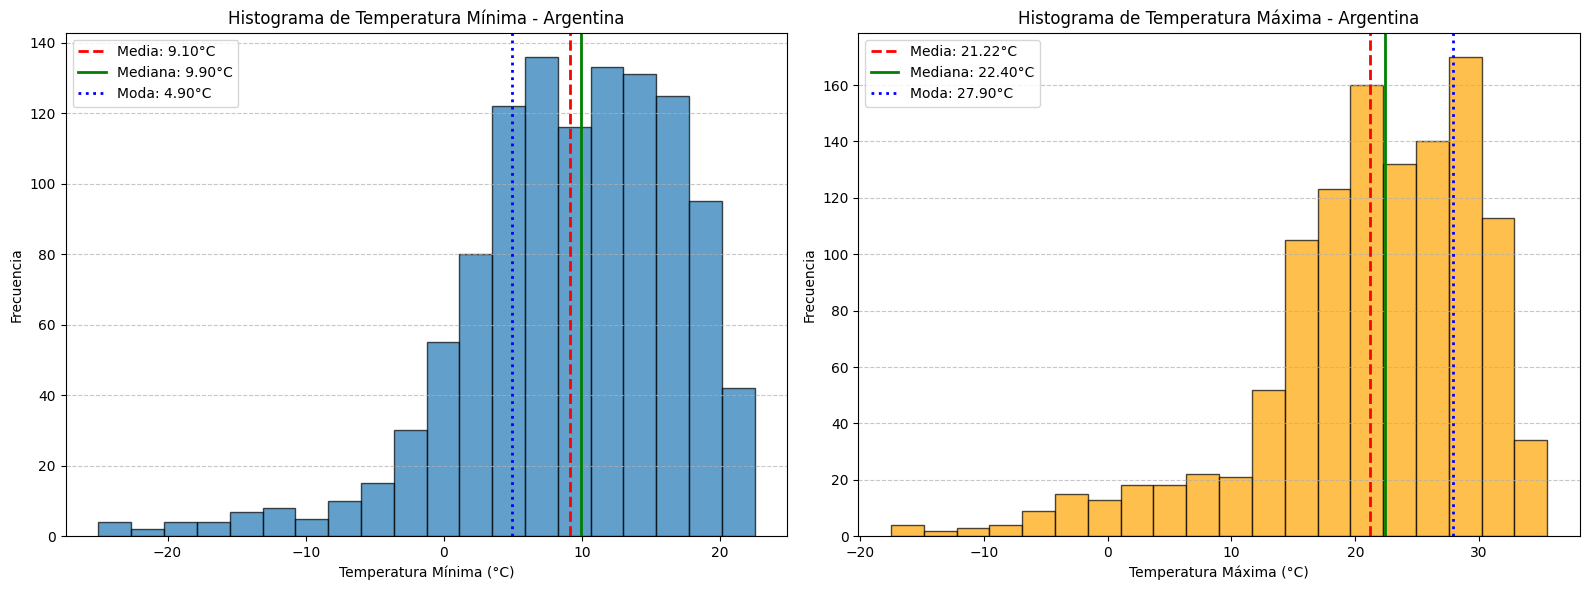

In [51]:
# Histogramas de temperatura mínima y máxima lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma de temperatura mínima
media_min = smn_historico['temp_min'].mean()
mediana_min = smn_historico['temp_min'].median()
moda_min = smn_historico['temp_min'].mode()[0]

axes[0].hist(smn_historico['temp_min'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(media_min, color='red', linestyle='--', linewidth=2, label=f'Media: {media_min:.2f}°C')
axes[0].axvline(mediana_min, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_min:.2f}°C')
axes[0].axvline(moda_min, color='blue', linestyle=':', linewidth=2, label=f'Moda: {moda_min:.2f}°C')
axes[0].set_xlabel('Temperatura Mínima (°C)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Histograma de Temperatura Mínima - Argentina')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Histograma de temperatura máxima
media_max = smn_historico['temp_max'].mean()
mediana_max = smn_historico['temp_max'].median()
moda_max = smn_historico['temp_max'].mode()[0]

axes[1].hist(smn_historico['temp_max'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(media_max, color='red', linestyle='--', linewidth=2, label=f'Media: {media_max:.2f}°C')
axes[1].axvline(mediana_max, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_max:.2f}°C')
axes[1].axvline(moda_max, color='blue', linestyle=':', linewidth=2, label=f'Moda: {moda_max:.2f}°C')
axes[1].set_xlabel('Temperatura Máxima (°C)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Histograma de Temperatura Máxima - Argentina')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()